# Task 3: Vectorized Convolutional Forward Pass via im2col
Pure NumPy implementation of a 2D convolution layer using the im2col transformation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

np.random.seed(42)


In [2]:
def im2col(input_data, filter_h, filter_w, stride=1, padding=0):
    N,C,H,W = input_data.shape

    out_h = (H + 2*padding - filter_h)//stride + 1
    out_w = (W + 2*padding - filter_w)//stride + 1

    img = np.pad(input_data,
                 [(0,0),(0,0),(padding,padding),(padding,padding)],
                 mode='constant')

    col = np.zeros((N,C,filter_h,filter_w,out_h,out_w))

    for y in range(filter_h):
        y_max = y + stride*out_h
        for x in range(filter_w):
            x_max = x + stride*out_w
            col[:,:,y,x,:,:] = img[:,:,y:y_max:stride,x:x_max:stride]

    col = col.transpose(0,4,5,1,2,3).reshape(N*out_h*out_w,-1)

    return col


In [3]:
class Conv2D:

    def __init__(self,in_channels,out_channels,kernel_size,
                 stride=1,padding=0):

        self.in_channels=in_channels
        self.out_channels=out_channels
        self.kernel_size=kernel_size
        self.stride=stride
        self.padding=padding

        kh,kw=kernel_size

        self.W=np.random.randn(out_channels,
                               in_channels,
                               kh,
                               kw)*0.1

        self.b=np.zeros(out_channels)

    def forward(self,x):

        N,C,H,W=x.shape

        kh,kw=self.kernel_size

        out_h=(H+2*self.padding-kh)//self.stride+1
        out_w=(W+2*self.padding-kw)//self.stride+1

        col=im2col(x,kh,kw,self.stride,self.padding)

        W_col=self.W.reshape(self.out_channels,-1)

        out=np.dot(col,W_col.T)+self.b

        out=out.reshape(N,out_h,out_w,self.out_channels)

        out=out.transpose(0,3,1,2)

        return out


In [4]:
N=2
C=3
H=W=32

X=np.random.randn(N,C,H,W)

conv=Conv2D(
    in_channels=3,
    out_channels=8,
    kernel_size=(3,3),
    stride=1,
    padding=1
)

output=conv.forward(X)

print("Input Shape :",X.shape)
print("Output Shape:",output.shape)


Input Shape : (2, 3, 32, 32)
Output Shape: (2, 8, 32, 32)


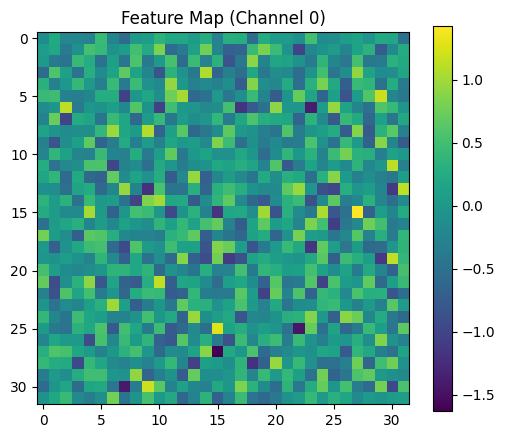

In [5]:
plt.figure(figsize=(6,5))
plt.imshow(output[0,0],cmap="viridis")
plt.title("Feature Map (Channel 0)")
plt.colorbar()
plt.show()
